# Pairs Trading with Spread Residual and Cycle Analysis

Pairs trading usually starts with a spread z-score. This notebook changes that rule to use a walk-forward De-Time residual z-score for the tradable stretch, while the spread trend is inspected as drift risk. A spread that trends persistently is often a broken relative-value trade, not a cheap entry.

**Default decomposition:** `ROBUST_STL` with a 63-trading-day period, computed walk-forward where signals are backtested.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from examples.quant_trading.data import fetch_yahoo_prices, fetch_yahoo_ohlcv, data_audit_report, DEFAULT_UNIVERSES
from examples.quant_trading.features import decompose_one_series, walkforward_decompose, build_feature_table
from examples.quant_trading.signals import (
    trend_pullback_signals,
    residual_mean_reversion_signals,
    turtle_donchian_signals,
    pair_trading_weights,
    cross_sectional_rotation_weights,
    residual_stress_filter,
)
from examples.quant_trading.backtest import backtest_weights, backtest_long_short_signals, summarize_returns

DATA_CACHE = Path("examples/quant_trading/data/cache")
QUANT_METHOD = "ROBUST_STL"
QUANT_PERIOD = 63


In [2]:
pair_prices = fetch_yahoo_prices(["KO", "PEP"], start="2016-01-01", cache_dir=DATA_CACHE)
spread = np.log(pair_prices["KO"]) - np.log(pair_prices["PEP"])
spread_panel = pd.DataFrame({"KO_PEP_spread": spread.add(100.0)})
spread_features = walkforward_decompose(
    spread_panel,
    method=QUANT_METHOD,
    period=QUANT_PERIOD,
    train_window=252,
    step=21,
    use_log_price=False,
)
spread_residual_z = spread_features["residual_z"]["KO_PEP_spread"].reindex(pair_prices.index).ffill()
weights = pair_trading_weights(pair_prices["KO"], pair_prices["PEP"], lookback=120, entry_z=1.5, exit_z=0.25, spread_residual_z=spread_residual_z)
classic_weights = pair_trading_weights(pair_prices["KO"], pair_prices["PEP"], lookback=120, entry_z=1.5, exit_z=0.25)
result = backtest_weights(pair_prices, weights, fee_bps=1.0, slippage_bps=2.0)
classic_result = backtest_weights(pair_prices, classic_weights, fee_bps=1.0, slippage_bps=2.0)
pair_comparison = pd.DataFrame({"detime_residual_spread": result.stats, "classic_spread_z": classic_result.stats}).T
pair_comparison

,total_return,cagr,volatility,sharpe,max_drawdown,calmar,hit_rate,average_turnover,average_gross_exposure,fee_bps,slippage_bps,periods_per_year
detime_residual_spread,0.113587,0.010434,0.034873,0.315006,-0.077011,0.135484,0.114855,0.012657,0.240046,1.0,2.0,252.0
classic_spread_z,0.082358,0.007665,0.064502,0.150697,-0.195764,0.039152,0.351838,0.021288,0.707887,1.0,2.0,252.0


## Decomposition rule map

The tradable stretch comes from the walk-forward spread residual, not from a full-sample decomposition. The trend is still plotted because persistent spread drift is a warning that the pair relationship may have changed.

In [3]:
pd.DataFrame([
    {"component": "spread trend", "feature": "walkforward_trend", "rule_role": "drift diagnostic", "strategy_effect": "persistent drift argues for shrinking or disabling the pair"},
    {"component": "spread residual", "feature": "residual_z > 1.5", "rule_role": "short KO / long PEP", "strategy_effect": "trade rich KO relative to PEP after removing trend/cycle structure"},
    {"component": "spread residual", "feature": "residual_z < -1.5", "rule_role": "long KO / short PEP", "strategy_effect": "trade cheap KO relative to PEP after removing trend/cycle structure"},
    {"component": "spread cycle", "feature": "season", "rule_role": "diagnostic", "strategy_effect": "check whether repeated calendar/cycle effects are driving residual entries"},
])

,component,feature,rule_role,strategy_effect
0,spread trend,walkforward_trend,drift diagnostic,persistent drift argues for shrinking or disab...
1,spread residual,residual_z > 1.5,short KO / long PEP,trade rich KO relative to PEP after removing t...
2,spread residual,residual_z < -1.5,long KO / short PEP,trade cheap KO relative to PEP after removing ...
3,spread cycle,season,diagnostic,check whether repeated calendar/cycle effects ...


In [4]:
spread_view = pd.DataFrame({
    "spread_plus_100": spread_panel["KO_PEP_spread"],
    "walkforward_trend": spread_features["trend"]["KO_PEP_spread"],
    "walkforward_season": spread_features["season"]["KO_PEP_spread"],
    "walkforward_residual_z": spread_residual_z,
})
spread_view.tail()

,spread_plus_100,walkforward_trend,walkforward_season,walkforward_residual_z
Date,,,,
2026-05-18,99.392566,99.287975,0.071523,0.049968
2026-05-19,99.392644,99.287975,0.071523,0.049968
2026-05-20,99.395326,99.287975,0.071523,0.049968
2026-05-21,99.393607,99.287975,0.071523,0.049968
2026-05-22,99.391160,99.287975,0.071523,0.049968


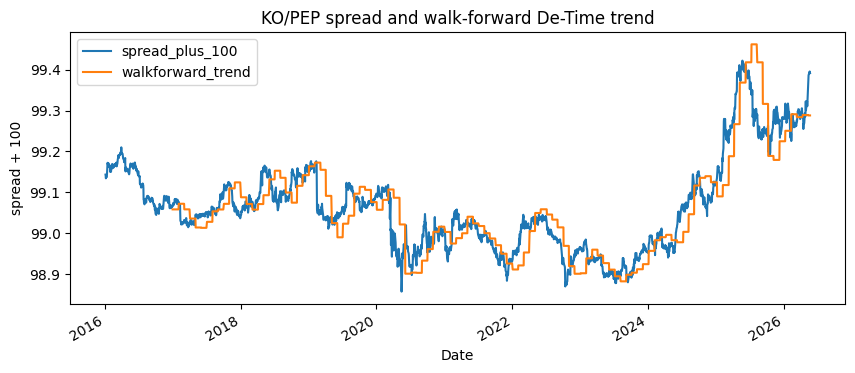

In [5]:
spread_view[["spread_plus_100", "walkforward_trend"]].plot(figsize=(10, 4), title="KO/PEP spread and walk-forward De-Time trend")
plt.ylabel("spread + 100")
plt.show()

## Visualization: spread residual bands and weights

Residual bands show where the pair is stretched; target weights show how the backtest responds.

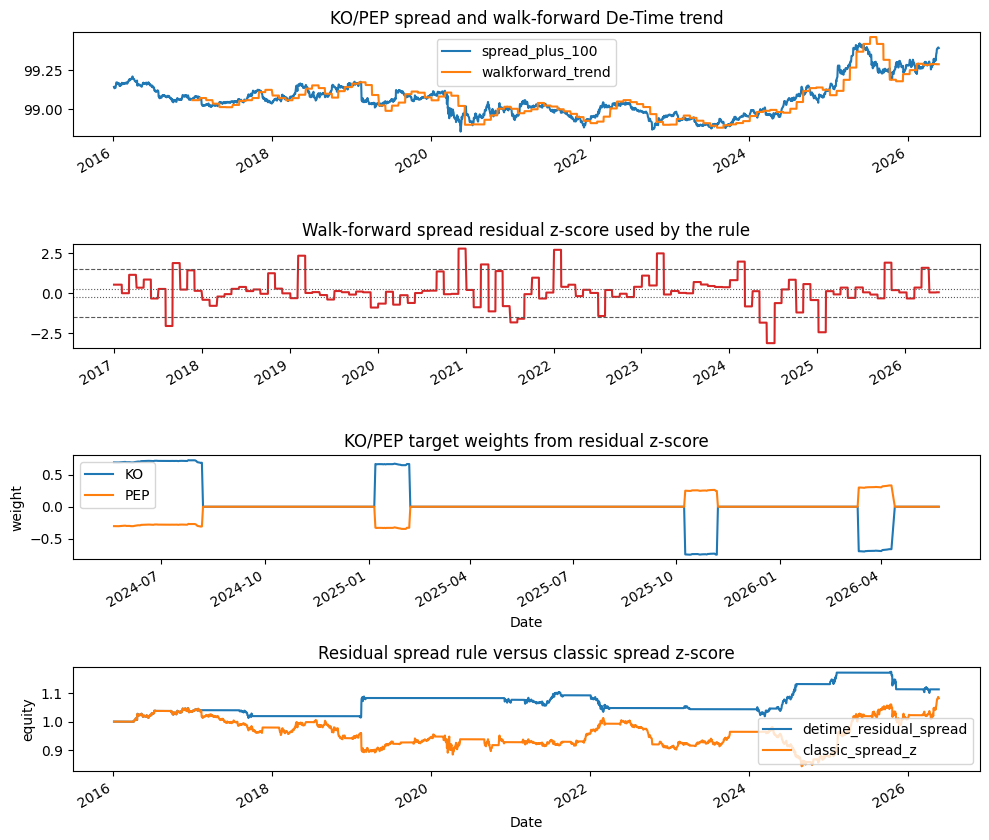

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8.5), sharex=False)
spread_view[["spread_plus_100", "walkforward_trend"]].plot(ax=axes[0], title="KO/PEP spread and walk-forward De-Time trend")
spread_view["walkforward_residual_z"].plot(ax=axes[1], color="tab:red", title="Walk-forward spread residual z-score used by the rule")
for level, style in [(1.5, "--"), (-1.5, "--"), (0.25, ":"), (-0.25, ":")]:
    axes[1].axhline(level, color="0.35", linestyle=style, linewidth=0.8)
weights.tail(504).plot(ax=axes[2], title="KO/PEP target weights from residual z-score")
pd.concat({"detime_residual_spread": result.equity, "classic_spread_z": classic_result.equity}, axis=1).plot(ax=axes[3], title="Residual spread rule versus classic spread z-score")
axes[0].set_xlabel("")
axes[1].set_xlabel("")
axes[2].set_ylabel("weight")
axes[3].set_ylabel("equity")
plt.tight_layout()
plt.show()